<a href="https://colab.research.google.com/github/brandy99swords/AIML2003_NLP/blob/main/week3%20/%20AIML_2003and2013_Module2_CombinedLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1: Setup

**What it does:** Installs nltk and scikit-learn, imports all libraries needed for the NLP section, and downloads the NLTK movie review corpus.  

**Import numpy as np:** used for array creation and mathematical operations.  
**Import TfidfVectorizer from sklearn.feature_extraction.text:** used to convert text into dense numerical vectors.  
**Import cosine_similarity from sklearn.metrics.pairwise:** used to measure how similar two feature vectors are (1 = identical direction, 0 = perpendicular).  
**Import matplotlib.pyplot and alias it plt:** used to visualize feature spaces.
**Import the movie_reviews dataset from nltk.corpus:** this is a corpus of 2,000 labeled movie reviews.  
**Import TSNE from sklearn.manifold:** used project high-dimensional feature spaces into 2D for visualization.  
  
**Print** a confirmation message stating that setup is complete.  
  
**Notes:** All packages (numpy, scikit-learn, nltk, matplotlib) are pre-installed in Colab. Use quiet=True on NLTK downloads to suppress verbose output.

In [26]:
# Cell 1: Setup
!pip install nltk scikit-learn google-generativeai -q

# General imports
import numpy as np
import time
import json
import matplotlib.pyplot as plt
import tensorflow as tf
import collections # Moved from Cell 9

# NLTK and scikit-learn for NLP
import nltk
nltk.download('movie_reviews', quiet=True)
nltk.download('stopwords', quiet=True)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from nltk.corpus import movie_reviews

# skimage for Computer Vision (HOG)
import skimage.transform
import skimage.color
import skimage.feature

# data table for comparison
import pandas as pd

# Google Generative AI
import google.generativeai as genai

# Global constants and placeholders
N_PER_CLASS = 15 # Number of images per class for CIFAR-10
TARGET_SIZE = 64 # Uniform size for images before HOG computation
hog_matrix = None # Placeholder for HOG feature matrix, will be populated later

print("Setup complete.")

Setup complete.


# Part 1: NLP Pipeline (Text as Feature Vectors)

## Cell 2: Load the corpus

**What it does:** Iterates over both categories of the movie review corpus (‘pos’ and ‘neg’), loads every document as a raw string, and builds two parallel lists. Prints a count and a short excerpt of the first review.

**Takes in:** movie_reviews (from Cell 1).

Create documents as a Python list of strings by looping over movie_reviews.fileids().
For each file ID, call movie_reviews.raw(fileid) to get the full text of that review. Append each text string to documents.

**Result:** a list of 2,000 review texts, one per file.

Create labels as a Python list of strings by extracting the category from each file ID (the category is the prefix before the first slash, e.g., 'pos' or 'neg').
Append the category string to labels parallel to documents.

**Result:** a list of 2,000 category labels, each either 'pos' or 'neg', in the same order as documents.

**Print** the total count of documents loaded and a brief excerpt (first 300 characters) of the first review so you can verify the text is being read correctly.

**Notes:** The corpus has exactly 1,000 positive and 1,000 negative reviews. File IDs are formatted as 'pos/cv001_1.txt' (category/filename). Use fileid.split('/') to extract the category part.

In [15]:
# Cell 2: Load the corpus
documents = []
labels = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append(movie_reviews.raw(fileid))
        labels.append(fileid.split('/')[0]) # Extract 'pos' or 'neg' from fileid

print(f"Corpus: {len(documents)} reviews")
print(f"Categories: {set(labels)}")
print(f"\nSample review (first 300 characters):\n{documents[0][:300]}...")

Corpus: 2000 reviews
Categories: {'neg', 'pos'}

Sample review (first 300 characters):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the...


###What is TF-IDF?

TF-IDF marks the inversion point where raw text is converted into numerical vectors. It calculates 'Term Frequency' based on how often a word appears in a document, then multiplies it by 'Inverse Document Frequency' which quantifies how unique that word is across the entire collection of texts. This combined score effectively measures a word's importance within a specific document relative to the corpus.

## Cell 3: Build TF-IDF feature vectors

**What it does:** Fits a TF-IDF vectorizer on the full documents list and transforms it into a sparse matrix. Prints the matrix shape and sparsity percentage. Then prints the top 10 TF-IDF terms for the very first document.
  
**Takes in:** `documents`, `labels` (from Cell 2).
  
**Create** `vectorizer` as an instance of `TfidfVectorizer` with these parameters: `max_features=5000` (keep only the 5,000 most frequent terms), `stop_words='english'` (ignore common words like “the” and “and”), `ngram_range=(1, 2)` (consider both individual words and pairs of consecutive words).  
  
**Call** `vectorizer.fit_transform(documents)` to learn the vocabulary from all 2,000 reviews and transform them into a sparse matrix in one step. Assign the result to `tfidf_matrix`.
`tfidf_matrix` will be a `scipy` sparse matrix of shape (2000, 5000) where row i is the TF-IDF vector for `documents[i]`. Each nonzero entry represents a term that appeared in that review, weighted by how unique it is across the corpus.  
  
**Extract** `feature_names` by calling `vectorizer.get_feature_names_out()`.  
  
**Convert** the result to a numpy array. This is an array of 5,000 strings, where index j is the term whose TF-IDF weight is stored at column j in every row of `tfidf_matrix`.  
  
**Print** the shape of `tfidf_matrix` and  
**compute** sparsity as the percentage of zero values: `1.0 - (matrix.nnz / (matrix.shape[0] * matrix.shape[1]))`. This is typically 99%+ because most words don't appear in most reviews.  
  
For `documents[0]`, **find its top 10 terms by:** converting its row to dense (`tfidf_matrix[0].toarray().flatten()`), getting indices of the top 10 weights (`np.argsort()` descending), and indexing into `feature_names` with those indices.   
  
**Print** these terms so you can see what TF-IDF considered most important for the first review.  
  
**Notes:** A sparse matrix stores only nonzero values, saving memory. The `.nnz` attribute gives the count of nonzero values. Most reviews will have zero weight for most of the 5,000 terms.

In [16]:
#Cell 3: Build TF-IDF feature vectors

# Create vectorizer as an instance of TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)
# Call vectorizer.fit_transform(documents) to learn the vocabulary and transform
tfidf_matrix = vectorizer.fit_transform(documents)

# Extract feature_names and Convert to a numpy array
feature_names = np.array(vectorizer.get_feature_names_out())

# Print the shape of tfidf_matrix
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

# Compute and Print sparsity
sparsity = 1.0 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)\n")

# For documents[0], find its top 10 terms
doc0_vector = tfidf_matrix[0].toarray().flatten()
top10_indices = doc0_vector.argsort()[-10:][::-1] # Get indices of top 10 weights, descending
top10_terms = feature_names[top10_indices]

# Print these terms
print(f"Top 10 TF-IDF terms for document 0:\n{top10_terms}")

TF-IDF Matrix Shape: (2000, 5000)
Sparsity: 0.9620 (96.20%)

Top 10 TF-IDF terms for document 0:
['10' 'teen' 'pretty' 'highway' 'crow' 'hide' 'make' 'mind' 'movie'
 'biggest']


###Example of Complete Review (for complete context and comparison only)

In [6]:
print(documents[0])

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience member , have no id

### Answering the questions on TF-IDF terms for document 0:

**Do they tell you whether the review is positive or negative?**

No. The most common words were 10, teen, pretty, highway, crow, hide, make, mind, movie, biggest. These terms seem to come more from the movie plot than the review's sentiment. The list contains only two adjectives pretty and biggest; the rest are nouns and verbs which do not often indicate sentiment.

**What kind of information does this vector not contain that a human reader would use?**

A human reader would consider factors like the most used adjectives, not just the most common words, to determine sentiment. Surrounding words and broader context are crucial and missing from this vector. Sentence structure and syntax are also ignored. Additionally, all uppercase words, which often indicate emphasis or anger, cannot be considered because all text is reduced to lowercase.

## Cell 4: Similarity retrieval

**What it does:** Defines a retrieval function, then calls it on one test query and prints the top 5 results with their labels and similarity scores.

**Takes in:** `vectorizer`, `tfidf_matrix`, `documents`, `labels` (from Cells 2–3).

**Define** a function `find_similar_texts(query, n=5)` that takes a plain-text string and finds the `n` most similar reviews in the corpus. Inside the function:

*   **Transform** the query string into a TF-IDF vector by calling `vectorizer.transform([query])`. This returns a 2D sparse matrix with one row.
*   **Compute** cosine similarity between the query vector and all 2,000 document vectors by calling `cosine_similarity(query_vector, tfidf_matrix)`. This returns a `(1, 2000)` array of similarity scores.
*   **Find** the indices of the top `n` scores (excluding the query itself if it appears in the corpus) by using `np.argsort()` in descending order.
*   For each of the top `n` indices, **create a tuple**: `(text_excerpt, label, similarity_score)` where `text_excerpt` is the first 220 characters of `documents[index]`, `label` is the corresponding element from `labels`, and `similarity_score` is the cosine similarity value.
*   **Return** a list of `n` tuples sorted from highest to lowest similarity.

**Test** the function with this query: "This film was a total waste of time. Terrible acting, boring plot."

**Print** the results in a readable format showing rank, label (in uppercase), similarity score (to 3 decimal places), and the first 200 characters of each matching review.

**Notes:** `vectorizer.transform([query])` expects a list, not a string. The query may not be in the corpus, so you don’t need to exclude it. Cosine similarity ranges from 0 (no overlap) to 1 (identical direction in feature space).

In [17]:
#Cell 4: Similarity retrieval

def find_similar_texts(query, n=5):
    # Transform the query string into a TF-IDF vector
    query_vector = vectorizer.transform([query])

    # Compute cosine similarity between the query vector and all document vectors
    # cosine_similarity returns a 2D array, so we flatten it to get a 1D array of scores
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Find the indices of the top n scores in descending order
    # Use argsort to get indices that would sort the array, then take the last n for top scores
    # [::-1] reverses the order to be descending
    top_n_indices = similarity_scores.argsort()[-n:][::-1]

    results = []
    for index in top_n_indices:
        text_excerpt = documents[index][:220] # First 220 characters
        label = labels[index]
        score = similarity_scores[index]
        results.append((text_excerpt, label, score))

    return results

# Test the function with the specified query
query_text = "This film was a total waste of time. Terrible acting, boring plot."
similar_reviews = find_similar_texts(query_text, n=5)

print(f"Top 5 similar reviews for query: '{query_text}'\n")
for i, (excerpt, label, score) in enumerate(similar_reviews):
    print(f"Rank {i+1}:\n  Label: {label.upper()}\n  Similarity: {score:.3f}\n  Excerpt: {excerpt}...\n")

Top 5 similar reviews for query: 'This film was a total waste of time. Terrible acting, boring plot.'

Rank 1:
  Label: NEG
  Similarity: 0.288
  Excerpt: this film is extraordinarily horrendous and i'm not going to waste any more words on it . 
...

Rank 2:
  Label: NEG
  Similarity: 0.228
  Excerpt:  " nothing more than a high budget masturbation fantasy " 
showgirls ( nc-17 ) - contains graphic nudity , profanity , sexual situations and violence . 
some people , however , keep their clothes on . 
you do not watch p...

Rank 3:
  Label: NEG
  Similarity: 0.162
  Excerpt: michael richards leaves his spot as kramer on the infamous seinfeld tv sitcom for a stint as a lanky , goofy best friend to jeff daniels' lawyer character in this ill-fated , and unfunny , " comedy " . 
plot : richard th...

Rank 4:
  Label: NEG
  Similarity: 0.157
  Excerpt: in the line of duty is the critically praised series of television movies dealing with the real-life incidents that claimed lives of law enforc

### Answering the questions on review similarity:

**How many of the top 5 results are negative reviews?**  
100% of the similar reviews were negative.  
**Did any positive reviews surface?**  
No.  
**If so, what words do they share with the query?**  
This requires a different query.

In [18]:
import collections

# Get the query text from Cell 4 (re-defined here for clarity in this cell)
query_text = "This film was a total waste of time. Terrible acting, boring plot."

# Get the TF-IDF vector for the query
query_tfidf_vector = vectorizer.transform([query_text])
# Get the indices of terms present in the query vector (non-zero entries)
query_term_indices = query_tfidf_vector.nonzero()[1]
query_terms = set(feature_names[query_term_indices])

# Initialize a counter for shared words
shared_word_counts = collections.Counter()

print(f"Query terms identified by TF-IDF vectorizer: {len(query_terms)} unique terms.\n")

# Iterate through the top 5 similar reviews obtained from Cell 4
# similar_reviews is a list of (text_excerpt, label, score)
for i, (excerpt, label, score) in enumerate(similar_reviews):
    # Get the TF-IDF vector for the current review excerpt
    review_tfidf_vector = vectorizer.transform([excerpt])
    # Get the indices of terms present in the review vector
    review_term_indices = review_tfidf_vector.nonzero()[1]
    review_terms = set(feature_names[review_term_indices])

    # Find the intersection of terms between the query and the current review
    common_terms_in_review = query_terms.intersection(review_terms)

    # Update the counter with these common terms
    shared_word_counts.update(common_terms_in_review)
    print(f"Review {i+1} (Label: {label.upper()}, Similarity: {score:.3f}): Found {len(common_terms_in_review)} common terms with query. Examples: {list(common_terms_in_review)[:5] if common_terms_in_review else 'None'}")

print("\nTop 5 most frequent shared words across the 5 similar reviews:")
# Get the top 5 most common words
top5_shared_words = shared_word_counts.most_common(5)

if top5_shared_words:
    for word, count in top5_shared_words:
        print(f"- '{word}' (appeared in {count} reviews)")
else:
    print("No common words found based on TF-IDF vocabulary between the query and top reviews.")


Query terms identified by TF-IDF vectorizer: 9 unique terms.

Review 1 (Label: NEG, Similarity: 0.288): Found 2 common terms with query. Examples: ['film', 'waste']
Review 2 (Label: NEG, Similarity: 0.228): Found 0 common terms with query. Examples: None
Review 3 (Label: NEG, Similarity: 0.162): Found 1 common terms with query. Examples: ['plot']
Review 4 (Label: NEG, Similarity: 0.157): Found 0 common terms with query. Examples: None
Review 5 (Label: NEG, Similarity: 0.154): Found 0 common terms with query. Examples: None

Top 5 most frequent shared words across the 5 similar reviews:
- 'film' (appeared in 1 reviews)
- 'waste' (appeared in 1 reviews)
- 'plot' (appeared in 1 reviews)


### Answering the questions on review similarity (part 2):

There were very few shared words between the reviews containing the greatest simliarity rating.
  
The strong cosine similarity scores indicate a conceptual alignment between the query and these reviews, even though their specific word choices showed minimal direct overlap.

In [19]:
# Cell 5: Find the failures

# Create a list named failure_queries
failure_queries = [
    ("This movie was absolutely not a waste of time.", "Same words as the Cell 4 query, but 'not' reverses the meaning."),
    ("I watched this film three times in one weekend.", "Strongly positive, but contains zero sentiment words."),
    ("I can't imagine anyone not enjoying this.", "Positive, but two negatives TF-IDF may misread."),
    ("A masterpiece. Stunning cinematography, a perfect score.", "Unambiguously positive: all strong positive adjectives.")
]

print("--- TF-IDF Failure Analysis ---\n")

# Loop through failure_queries
for query_string, note in failure_queries:
    print(f"Query: '{query_string}'")
    print(f"Note: {note}")

    # Call find_similar_texts to retrieve the 5 most similar reviews
    similar_reviews_results = find_similar_texts(query_string, n=5)

    # Count how many of the top 5 results have label == 'pos' and how many have label == 'neg'
    pos_count = 0
    neg_count = 0

    for _, label, _ in similar_reviews_results:
        if label == 'pos':
            pos_count += 1
        elif label == 'neg':
            neg_count += 1

    print(f"  Top 5 results: {pos_count} positive, {neg_count} negative\n")

print("--- Analysis Complete ---")


--- TF-IDF Failure Analysis ---

Query: 'This movie was absolutely not a waste of time.'
Note: Same words as the Cell 4 query, but 'not' reverses the meaning.
  Top 5 results: 0 positive, 5 negative

Query: 'I watched this film three times in one weekend.'
Note: Strongly positive, but contains zero sentiment words.
  Top 5 results: 3 positive, 2 negative

Query: 'I can't imagine anyone not enjoying this.'
Note: Positive, but two negatives TF-IDF may misread.
  Top 5 results: 1 positive, 4 negative

Query: 'A masterpiece. Stunning cinematography, a perfect score.'
Note: Unambiguously positive: all strong positive adjectives.
  Top 5 results: 3 positive, 2 negative

--- Analysis Complete ---


### Explaining TF-IDF's behavior with failure queries:

**For each of the four queries, explain in one sentence why TF-IDF got confused (or didn’t).**

1. "This movie was absolutely not a waste of time."**
TF-IDF got confused because it primarily measures term frequency and inverse document frequency, effectively ignoring the crucial negative word 'not' which reverses the sentiment.

2. "I watched this film three times in one weekend."**
TF-IDF got confused because this query expresses positive sentiment through implication and repetition, but lacks direct 'sentiment words' that the vectorizer would heavily weight.

3. "I can't imagine anyone not enjoying this."**
TF-IDF got confused by the double negation; it struggles with complex sentence structures and the interplay of multiple negative words that collectively convey a positive sentiment.

4. "A masterpiece. Stunning cinematography, a perfect score."**
TF-IDF correctly identified similar reviews because this query contains strong, explicit positive adjectives that are highly weighted and contribute directly to a positive vector direction.  
  
**What is it measuring that caused the result?**  
TF-IDF quantifies the importance of terms by analyzing their occurrence within documents and rarity across the entire corpus. While it relies on word frequencies, cosine similarity then measures the directional alignment of these resulting 'topic vectors'. This allows it to identify documents with similar overall meaning or sentiment, even if they don't share many exact words.

# Part 2: CV Pipeline (Images as Feature Vectors)

## Cell 6: Load CIFAR-10

**What it does:** Loads the CIFAR-10 training set via Keras, takes 15 images per class (150 total), and displays a grid showing one sample from each class.

**Takes in:** Nothing external. This is the image dataset loader.  
  
*   **Load CIFAR-10** by calling tf.keras.datasets.cifar10.load_data(). This returns a tuple ((train_images, train_labels), (test_images, test_labels)). Use only the training split.
*   **Unpack it:** train_images and train_labels.
*   **Create images** by selecting exactly 15 images from each of the 10 classes, ordered class by class. Use numpy indexing to extract rows where train_labels == 0 (first 15), then train_labels == 1 (next 15), etc.
*   **Stack them vertically.**  

**Result:** numpy array of shape (150, 32, 32, 3), dtype uint8 (pixel values 0–255).  
  
*   **Create img_labels** as a Python list of length 150, where the first 15 elements are 0, the next 15 are 1, etc. up to 9. This encodes which class each image belongs to.
*   **Create img_names** as a Python list of class name strings, exactly: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']. Length 150, with each name repeated 15 times in order. This is parallel to img_labels.
*   **Set N_PER_CLASS = 15 as an integer constant.** Later cells use this to index the first image from each class.
*   **Display** a grid showing one representative image from each of the 10 classes. Use plt.subplots(2, 5) to create a 2×5 grid, iterate over the 10 class indices, and display the first image of each class with the class name as the title.  
  
**Notes:** CIFAR-10 is pre-installed in Keras (no download needed in Colab). Each image is 32×32 pixels in RGB (3 channels). The class labels in the loaded dataset are integers 0–9; map them to readable names using img_names.

Loaded 150 images.
Shape of images: (150, 32, 32, 3)
Example img_labels (first 30): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Example img_names (first 30): ['airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile']


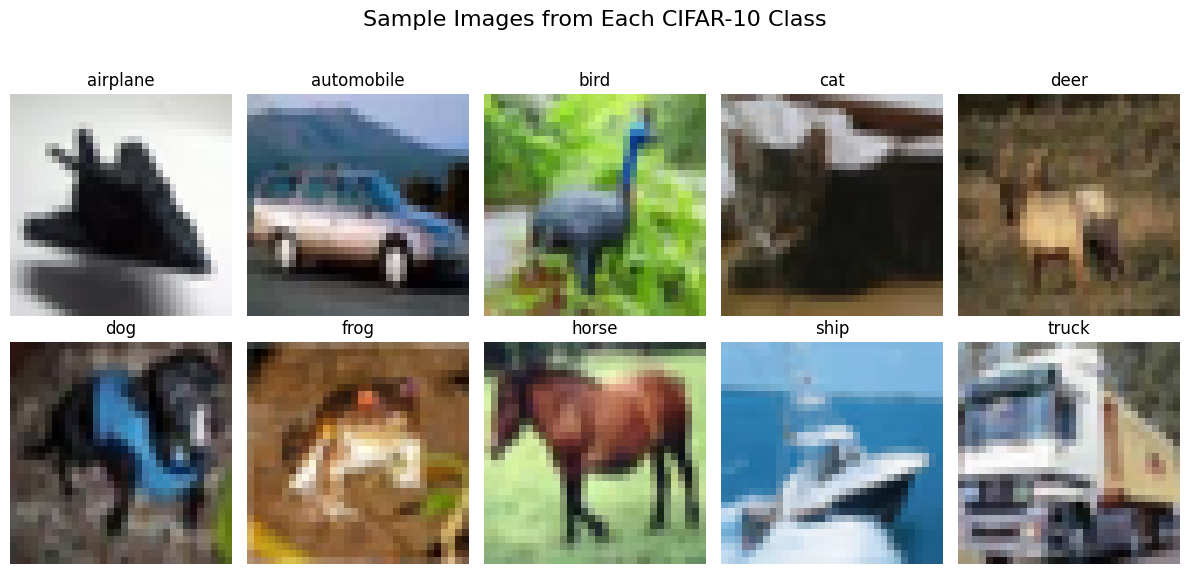

In [20]:
# Cell 6: Load CIFAR-10

# Load CIFAR-10
(train_images, train_labels), _ = tf.keras.datasets.cifar10.load_data()

# N_PER_CLASS is now a global variable defined in Cell 1

# Class names for CIFAR-10
cifar10_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

images = []
img_labels = []
img_names = []

# Select N_PER_CLASS images from each of the 10 classes
for i in range(10): # 10 classes in CIFAR-10
    # Get indices for the current class
    class_indices = np.where(train_labels.flatten() == i)[0]
    # Select N_PER_CLASS images for this class
    selected_images_for_class = train_images[class_indices[:N_PER_CLASS]]

    images.extend(selected_images_for_class)
    img_labels.extend([i] * N_PER_CLASS)
    img_names.extend([cifar10_class_names[i]] * N_PER_CLASS)

# Convert images list to a numpy array
images = np.array(images)

print(f"Loaded {len(images)} images.")
print(f"Shape of images: {images.shape}")
print(f"Example img_labels (first {N_PER_CLASS*2}): {img_labels[:N_PER_CLASS*2]}")
print(f"Example img_names (first {N_PER_CLASS*2}): {img_names[:N_PER_CLASS*2]}")

# Display a grid showing one representative image from each of the 10 classes
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i in range(10):
    # Get the index of the first image for each class
    idx = i * N_PER_CLASS
    axes[i].imshow(images[idx])
    axes[i].set_title(cifar10_class_names[img_labels[idx]])
    axes[i].axis('off')

plt.suptitle("Sample Images from Each CIFAR-10 Class", fontsize=16)
fig.subplots_adjust(hspace=0.5, wspace=.1) # Added to adjust spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Describe what you think a “feature vector for an image” should capture. If you could describe an image with only 1,500 numbers, which 1,500 would you choose? Write your answer now. You’ll compare it to what HOG actually does.

## Cell 7: Compute HOG feature vectors

**What it does:** Defines a function that converts a single color image to a HOG feature vector and a visualization image, then applies it to every image in `images`. Prints the shape of the resulting feature matrix and a comparison to the TF-IDF matrix dimensions. Displays a 3-column grid (original → grayscale → HOG visualization) for three sample images.

**Takes in:** `images`, `img_names`, `N_PER_CLASS`, `tfidf_matrix` (for the dimension comparison printout).

**Define** a helper function `image_to_hog(image)` that:
*   Takes a single image (a numpy array of any size, RGB or grayscale).
*   Resizes it to `TARGET_SIZE × TARGET_SIZE` pixels using `skimage.transform.resize(image, (TARGET_SIZE, TARGET_SIZE))`.  
*   Converts to grayscale using `skimage.color.rgb2gray()` if the image has 3 channels; if it’s already grayscale, use it directly.
*   Calls `skimage.feature.hog(grayscale_image, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)`. This returns a tuple (`hog_descriptor`, `hog_image`).
*   Returns both the descriptor array and the visualization image.
*   **Set** a constant `TARGET_SIZE = 64`. This is the uniform size all images will be resized to before HOG computation.
*   **Loop** over every image in `images`. For each, call `image_to_hog(image)`, collect all descriptors into `hog_matrix` (stacked vertically), and collect all visualization images into `hog_visuals` (a Python list).
    *   `hog_matrix` will be a numpy array of shape `(len(images), 1152)` for `TARGET_SIZE=64` (the number of HOG features depends on the orientation and cell parameters; 1152 is typical for 8 orientations, 8×8-pixel cells, 2×2-cell blocks on a 64×64 image).
    *   `hog_visuals` will be a list of 2D grayscale arrays, one per image, suitable for display with `plt.imshow(..., cmap='gray')`.

**Print** the shape of `hog_matrix` and a short comparison: how many features does HOG produce vs. how many does TF-IDF produce? (You have `tfidf_matrix` from Cell 3, which has shape `(2000, 5000)`.)  

**Display** a 3-column grid showing three example images: original, grayscale, and HOG visualization. Use three sample indices: `0` (first image from class 0), `N_PER_CLASS` (first image from class 1), and `N_PER_CLASS * 2` (first image from class 2).

**Notes:** HOG stands for Histogram of Oriented Gradients. The `visualize=True` flag is essential: without it, `hog()` returns only the descriptor. `orientations=8` means 8 directions for edges. `pixels_per_cell=(8, 8)` means the image is divided into 8-pixel × 8-pixel cells. `cells_per_block=(2, 2)` means features are normalized over 2×2 blocks of cells. All packages (scikit-image, numpy) are pre-installed in Colab.

HOG Feature Matrix Shape: (150, 1568)
TF-IDF Feature Matrix Shape: (2000, 5000)
Comparison: HOG produces 1568 features per image, while TF-IDF produces 5000 features per document.


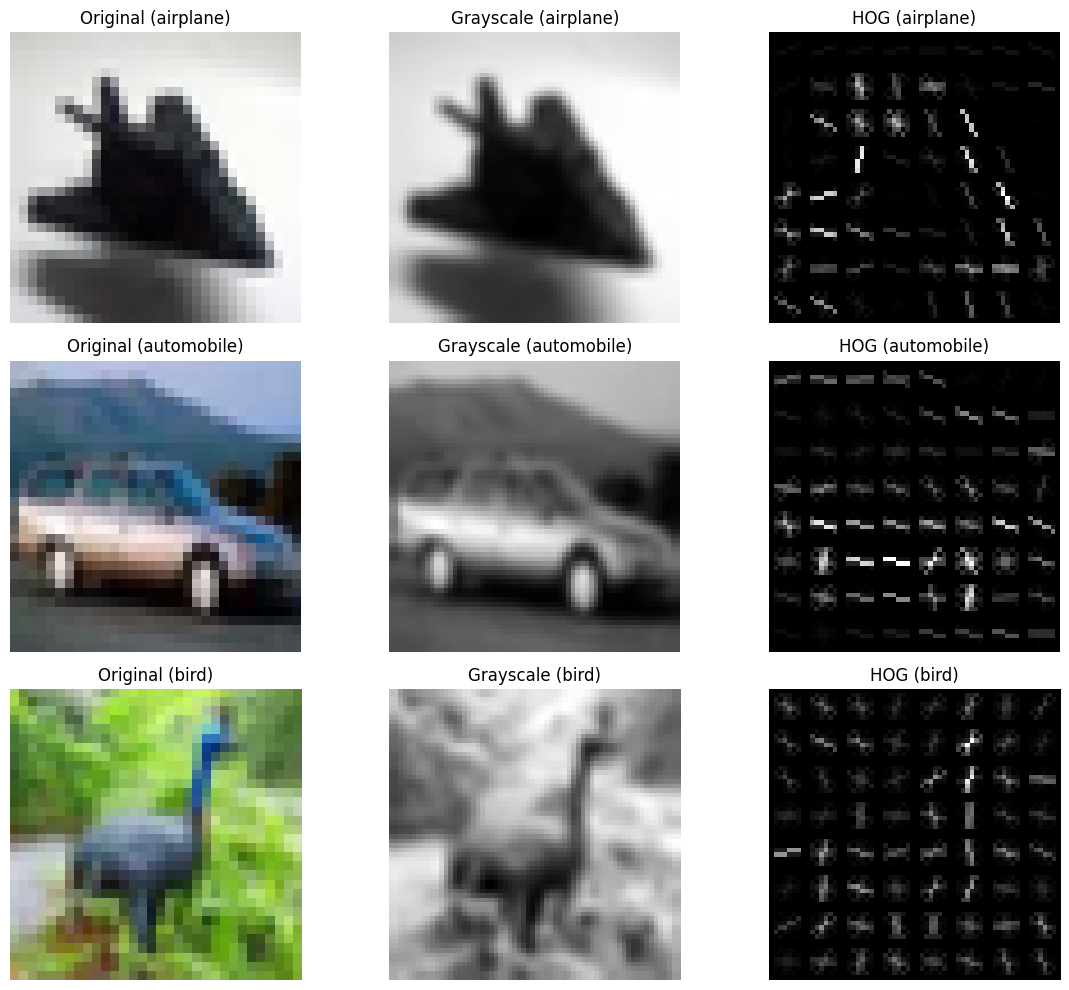

In [28]:
# Cell 7: Compute HOG feature vectors

# TARGET_SIZE is now a global variable defined in Cell 1
# N_PER_CLASS is now a global variable defined in Cell 1

def image_to_hog(image):
    # Resize the image
    resized_image = skimage.transform.resize(image, (TARGET_SIZE, TARGET_SIZE), anti_aliasing=True)

    # Convert to grayscale if it's a color image
    if resized_image.shape[-1] == 3:
        grayscale_image = skimage.color.rgb2gray(resized_image)
    else:
        grayscale_image = resized_image

    # Compute HOG features and visualization
    hog_descriptor, hog_image = skimage.feature.hog(
        grayscale_image,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True,
        feature_vector=True
    )
    return hog_descriptor, hog_image

# Loop over every image in images to compute HOG features
hog_matrix_list = [] # Using a temporary list to collect descriptors
hog_visuals = []

for img in images:
    descriptor, visual = image_to_hog(img)
    hog_matrix_list.append(descriptor)
    hog_visuals.append(visual)

# Assign to the global hog_matrix
hog_matrix = np.array(hog_matrix_list)

print(f"HOG Feature Matrix Shape: {hog_matrix.shape}")

# Check if tfidf_matrix is defined before trying to access its shape
if 'tfidf_matrix' in globals():
    print(f"TF-IDF Feature Matrix Shape: {tfidf_matrix.shape}")
    print(f"Comparison: HOG produces {hog_matrix.shape[1]} features per image, while TF-IDF produces {tfidf_matrix.shape[1]} features per document.")
else:
    print("TF-IDF Feature Matrix (tfidf_matrix) is not defined. Please run the NLP pipeline (Cell 3) to compute TF-IDF features for comparison.")

# Display a 3-column grid showing three example images
sample_indices = [0, N_PER_CLASS, N_PER_CLASS * 2] # First image from class 0, 1, and 2

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 10))

for i, idx in enumerate(sample_indices):
    original_image = images[idx]

    # Resize and convert to grayscale for intermediate display
    resized_original = skimage.transform.resize(original_image, (TARGET_SIZE, TARGET_SIZE), anti_aliasing=True)
    if resized_original.shape[-1] == 3:
        grayscale_image_display = skimage.color.rgb2gray(resized_original)
    else:
        grayscale_image_display = resized_original

    hog_visual = hog_visuals[idx]
    image_name = img_names[idx]

    # Original Image
    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title(f"Original ({image_name})")
    axes[i, 0].axis('off')

    # Grayscale Image (resized)
    axes[i, 1].imshow(grayscale_image_display, cmap='gray')
    axes[i, 1].set_title(f"Grayscale ({image_name})")
    axes[i, 1].axis('off')

    # HOG Visualization
    axes[i, 2].imshow(hog_visual, cmap='gray')
    axes[i, 2].set_title(f"HOG ({image_name})")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Explaining HOG Feature Vectors

Look at the HOG visualizations. The bright lines show where gradients are strongest and in which direction.   

**What has HOG kept from the original image?**  
  
Looking at the HOG visualizations, HOG primarily captures and emphasizes gradient directions within an image. These gradients show where pixel intensity changes significantly, which is what defines edges and structural outlines. Here's what I observed for the specific images:

*   **The airplane image**: HOG clearly defined its edges and the direction of these changes, showing its form well.
*   **The car image**: This was a little more difficult to interpret. I see some radial identifiers and estimated differences between the object and the background, but no clear defining lines, only the gradient directions.
*   **The bird image**: HOG successfully highlighted the neck and body by showing their prominent gradient directions, clearly identifying the differences where the head is located, so an overall shape can be identified.
   
**What has it thrown away?**  
  
What HOG has thrown away are details like the original colors, fine textures, and exact pixel values, focusing strictly on these gradient patterns.
  
**Compare this to what TF-IDF kept and discarded from text: what is the same about both transformations?**  
  
This process is similar to TF-IDF for text. Both methods aim to transform complex raw data (pixels for HOG, words for TF-IDF), into a more abstract, numerical feature vector. TF-IDF keeps terms important to a document and unique across the library of documents, while discarding common words and complex sentence structures. The similarity is that both HOG and TF-IDF reduce high-dimensional raw data into a more concise feature set, emphasizing key characteristics (gradient directions for images, significant terms for text) while omitting features that may be less critical for calculations or redundant information for machine learning.

## Cell 8: Visual similarity retrieval  
  
**What it does:** Defines a retrieval function that finds the most visually similar images by HOG cosine similarity, then runs it on three query images and displays the results as image grids.  
  
**Takes in:** hog_matrix, images, img_names, N_PER_CLASS (from Cells 6–7).  
  
**Define** a function find_similar_images(query_idx, n=5) that:
Takes an integer index query_idx (into images and hog_matrix).  

**Computes cosine similarity** between the query’s HOG vector and all HOG vectors by calling cosine_similarity(hog_matrix[query_idx:query_idx+1], hog_matrix). This returns a (1, n_images) array of similarity scores.  
**Set the query’s own similarity score** to -1 (so it doesn’t appear in the results).  
**Find the indices** of the top n scores using np.argsort() in descending order.  
  
**Return** two parallel arrays: top_indices (the n indices with the highest similarity, excluding the query) and sim_scores (their corresponding similarity scores).  
  
**Test the function** on three query indices: 0, N_PER_CLASS, and N_PER_CLASS * 2. These are the first image from each of the first three classes.
For each query, display a matplotlib figure with 6 subplots in one row:
Leftmost (column 0): the query image with title “QUERY”.
Next 5 columns: the 5 most similar images returned by find_similar_images, with titles formatted as: “classname” followed by a checkmark (“\u2713”) if the retrieved image’s class matches the query class, or an X (“\u2717”) if it does not. Also include the similarity score (to 2 decimal places) below the class name.  
  
**Notes:** Cosine similarity ranges from 0 to 1. If a result is visually similar but a different class (e.g., a “cat” that looks like a “dog”), mark it with an X. These misclassifications are learning moments: they reveal what HOG can and cannot see.

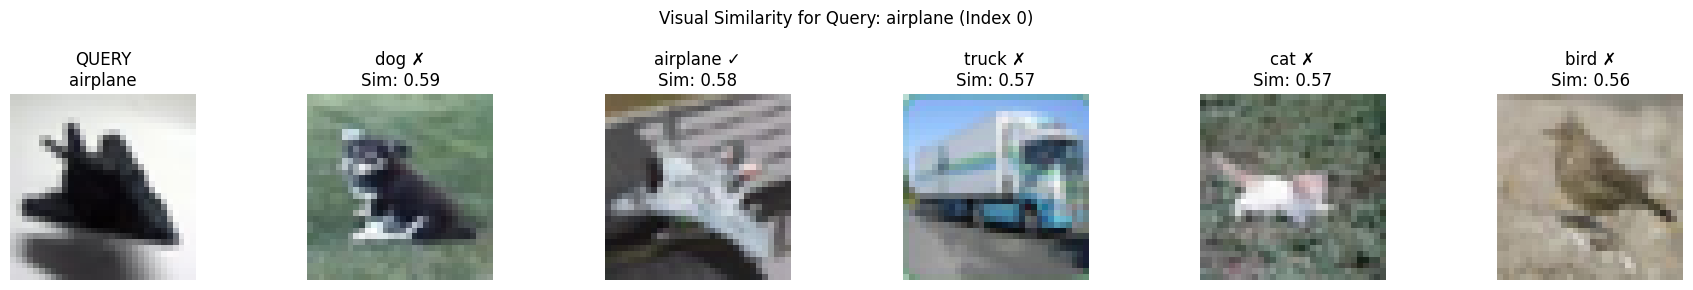

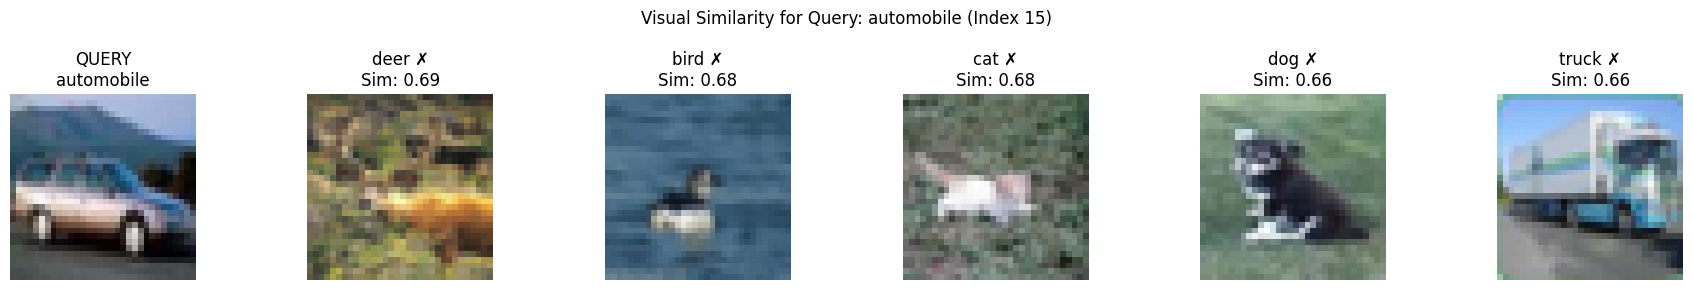

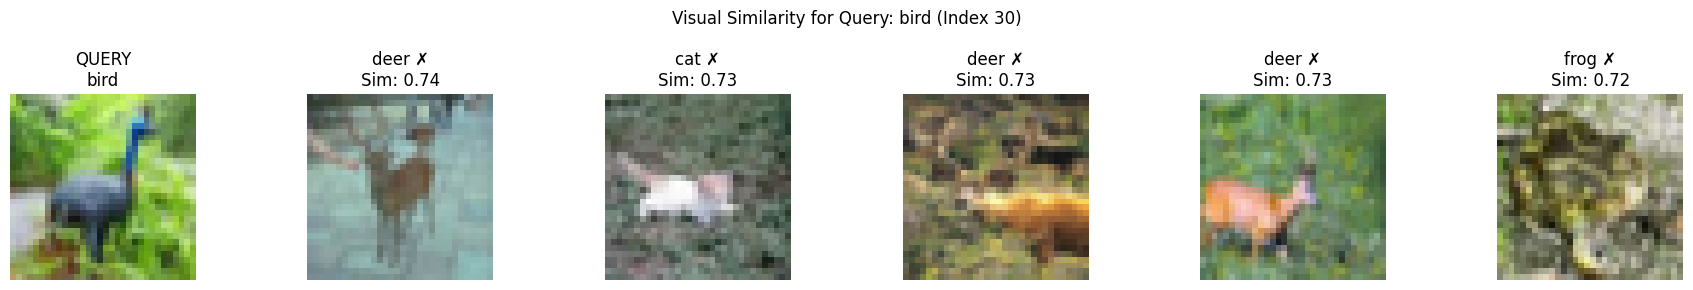

In [22]:
# Cell 8: Visual similarity retrieval

def find_similar_images(query_idx, n=5):
    # Compute cosine similarity between the query's HOG vector and all HOG vectors
    # hog_matrix[query_idx:query_idx+1] ensures it's a 2D array for cosine_similarity
    similarity_scores = cosine_similarity(hog_matrix[query_idx:query_idx+1], hog_matrix).flatten()

    # Set the query's own similarity score to -1 so it doesn't appear in the results
    similarity_scores[query_idx] = -1

    # Find the indices of the top n scores in descending order
    # argsort returns indices that would sort an array, taking last n and reversing gets top n
    top_indices = similarity_scores.argsort()[-n:][::-1]
    sim_scores = similarity_scores[top_indices]

    return top_indices, sim_scores

# Test the function on three query indices
query_indices_to_test = [0, N_PER_CLASS, N_PER_CLASS * 2]

for query_idx in query_indices_to_test:
    top_indices, sim_scores = find_similar_images(query_idx, n=5);

    # Get query image details
    query_image = images[query_idx]
    query_class_label = img_labels[query_idx]
    query_class_name = img_names[query_idx]

    fig, axes = plt.subplots(1, 6, figsize=(18, 3))

    # Plot query image
    axes[0].imshow(query_image)
    axes[0].set_title(f"QUERY\n{query_class_name}")
    axes[0].axis('off')

    # Plot similar images
    for i in range(5):
        idx = top_indices[i]
        score = sim_scores[i]
        similar_image = images[idx]
        similar_class_label = img_labels[idx]
        similar_class_name = img_names[idx]

        # Determine checkmark or X
        match_symbol = '\u2713' if similar_class_label == query_class_label else '\u2717'

        axes[i+1].imshow(similar_image)
        axes[i+1].set_title(f"{similar_class_name} {match_symbol}\nSim: {score:.2f}")
        axes[i+1].axis('off')

    plt.suptitle(f"Visual Similarity for Query: {query_class_name} (Index {query_idx})")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Explaining Visual Simliarity

For each retrieval:  
  
**How many of the top 5 are the same class as the query?**  
  
*   **Row 1:** Only 1 other image is the same class  
*   **Row 2:** No other image is in the same class, although it did pickup a truck that is in a similar class
*   **Row 3:** No other images are birds, but they are all images of animals
  
Find at least one wrong result. Look at both images:

**What do they visually share that fooled HOG?**  

In Row 1, the image of the dog is in the same direction with the same directional contrast. Both the airplane and dog are in the shape of an arrow. This resulted from similar directional gradients, but other features that were dropped make it clear they are not the same class.

## Cell 9: Systematic failure analysis

**What it does:** Loops over the first 40 images, runs retrieval for each, records every case where the top-1 match is a different class than the query. Prints a summary of the most commonly confused class pairs. Then visualizes the single most interesting failure in a 2×3 grid: original image, grayscale, and HOG visualization for both the query and the wrong match.

**Takes in:** find_similar_images, images, img_names, hog_visuals, N_PER_CLASS, image_to_hog, TARGET_SIZE (from Cells 6–7).

**Loop over the first 40 images** in the dataset (indices 0 to 39 or 0 to 34, depending on how many images you have per class).  
For each image:
**Call** find_similar_images(query_idx, n=1) to find the single most similar image.
**Check** if the retrieved image’s class (img_names[top_indices[0]]) matches the query’s class (img_names[query_idx]).  
If they do not match, record a failure as a dictionary: {'query_idx': query_idx, 'query_class': img_names[query_idx], 'match_idx': top_indices[0], 'match_class': img_names[top_indices[0]], 'score': sim_scores[0]}.  

**Create** failures as a Python list of these dictionaries, sorted by 'score' in descending order (highest-confidence mistakes first).  
  
**Print a summary:** the total number of failures found, and the top-5 most frequently confused class pairs (e.g., “cat confused with dog: 3 times”).  
  
**Visualize** the single highest-confidence failure (the one at failures[0]) in a 2×3 matplotlib grid:  
Row 0 (query image): original RGB, grayscale, HOG visualization.  
Row 1 (retrieved image that was wrong): original RGB, grayscale, HOG visualization.  
Each subplot should have a title identifying the image (e.g., “Query (cat)” and “Retrieved (dog)”) and the similarity score.  
  
**Notes:** The grayscale version of each image is computed by resizing to (TARGET_SIZE, TARGET_SIZE) and calling rgb2gray() from skimage. The HOG visualization for each image is already stored in hog_visuals[image_idx]. This cell reveals what HOG missed: why it thought two different classes were similar.

Total number of top-1 classification failures found: 35

Top 5 most frequently confused class pairs:
- bird confused with deer: 5 times
- automobile confused with frog: 5 times
- airplane confused with cat: 5 times
- airplane confused with frog: 3 times
- airplane confused with deer: 3 times

Visualizing highest-confidence failure (Score: 0.77):
Query: airplane (Index: 4) -> Matched: frog (Index: 92)


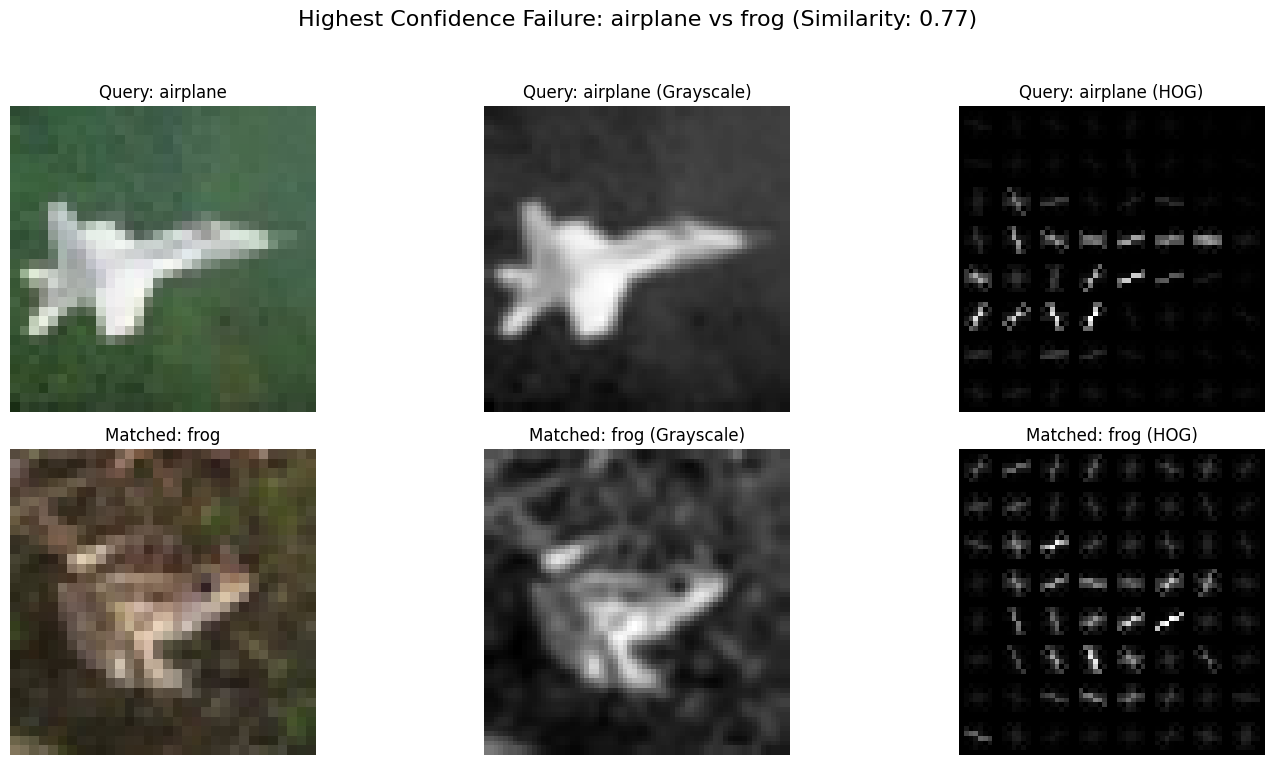

In [23]:
# Cell 9: Systematic failure analysis

# Initialize a list to store failures
failures = []

# Loop over the first 40 images (indices 0 to 39)
# You can adjust this range if N_PER_CLASS is different or you want to analyze more/fewer images.
for query_idx in range(40):
    # Find the single most similar image
    top_indices, sim_scores = find_similar_images(query_idx, n=1)

    # Get details for the query image
    query_class_name = img_names[query_idx]

    # Get details for the top-1 matched image
    match_idx = top_indices[0]
    match_class_name = img_names[match_idx]
    similarity_score = sim_scores[0]

    # Check if the retrieved image's class is different from the query's class
    if query_class_name != match_class_name:
        failures.append({
            'query_idx': query_idx,
            'query_class': query_class_name,
            'match_idx': match_idx,
            'match_class': match_class_name,
            'score': similarity_score
        })

# Sort failures by 'score' in descending order (highest-confidence mistakes first)
failures.sort(key=lambda x: x['score'], reverse=True)

print(f"Total number of top-1 classification failures found: {len(failures)}\n")

# Summarize the most commonly confused class pairs
confused_pairs_counter = collections.Counter()
for failure in failures:
    # Ensure consistent order for counting pairs (e.g., ('cat', 'dog') vs ('dog', 'cat'))
    pair = tuple(sorted((failure['query_class'], failure['match_class'])))
    confused_pairs_counter[pair] += 1

print("Top 5 most frequently confused class pairs:")
for (class1, class2), count in confused_pairs_counter.most_common(5):
    print(f"- {class1} confused with {class2}: {count} times")

# Visualize the single highest-confidence failure (if any)
if failures:
    highest_confidence_failure = failures[0]
    query_idx = highest_confidence_failure['query_idx']
    query_class = highest_confidence_failure['query_class']
    match_idx = highest_confidence_failure['match_idx']
    match_class = highest_confidence_failure['match_class']
    score = highest_confidence_failure['score']

    print(f"\nVisualizing highest-confidence failure (Score: {score:.2f}):")
    print(f"Query: {query_class} (Index: {query_idx}) -> Matched: {match_class} (Index: {match_idx})")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    plt.suptitle(f"Highest Confidence Failure: {query_class} vs {match_class} (Similarity: {score:.2f})", fontsize=16)

    # Query image row
    # Original RGB
    axes[0, 0].imshow(images[query_idx])
    axes[0, 0].set_title(f"Query: {query_class}")
    axes[0, 0].axis('off')

    # Grayscale (resized)
    query_gray_resized = skimage.color.rgb2gray(skimage.transform.resize(images[query_idx], (TARGET_SIZE, TARGET_SIZE), anti_aliasing=True))
    axes[0, 1].imshow(query_gray_resized, cmap='gray')
    axes[0, 1].set_title(f"Query: {query_class} (Grayscale)")
    axes[0, 1].axis('off')

    # HOG Visualization
    axes[0, 2].imshow(hog_visuals[query_idx], cmap='gray')
    axes[0, 2].set_title(f"Query: {query_class} (HOG)")
    axes[0, 2].axis('off')

    # Matched image row
    # Original RGB
    axes[1, 0].imshow(images[match_idx])
    axes[1, 0].set_title(f"Matched: {match_class}")
    axes[1, 0].axis('off')

    # Grayscale (resized)
    match_gray_resized = skimage.color.rgb2gray(skimage.transform.resize(images[match_idx], (TARGET_SIZE, TARGET_SIZE), anti_aliasing=True))
    axes[1, 1].imshow(match_gray_resized, cmap='gray')
    axes[1, 1].set_title(f"Matched: {match_class} (Grayscale)")
    axes[1, 1].axis('off')

    # HOG Visualization
    axes[1, 2].imshow(hog_visuals[match_idx], cmap='gray')
    axes[1, 2].set_title(f"Matched: {match_class} (HOG)")
    axes[1, 2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No top-1 classification failures found in the first 40 images.")

##Explaining Systematic failure analysis

For your best failure: Describe in plain language what HOG noticed in both images and why it treated them as similar. A human would not make this mistake. What does a human use that HOG cannot see?  
  
HOG noticed the overall shape and direction of the shape along with contrast of the main subject against the background, but color makes a massive difference in determining the class of an image, not only gradient direction and image contrast. HOG detects edges very effectively, but all things in life and the physical universe can be degregated to the shape of a triangle - PI. We have a significantly larger amount of data that can be evaluated in order to determine the subject of an iamge and what class it belongs to.

## Cell 10: Side-by-side summary table

**What it does:** Prints a formatted comparison table of TF-IDF and HOG properties, computed from variables already in the notebook. No new analysis. This is a synthesis cell.

**Takes in:** tfidf_matrix, hog_matrix.

**A printed comparison table with these rows:**

*   **Input type:** Hard-coded string “Text” for TF-IDF, “Images” for HOG.  
*   **Feature dimensions:** Computed from your actual matrices. For TF-IDF: tfidf_matrix.shape[1] (should be 5,000). For HOG: hog_matrix.shape[1] (should be around 1,152).
*   **Sparsity (%):** Computed from your matrices. For TF-IDF: (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100 (expect 99%+). For HOG: (np.sum(hog_matrix == 0) / hog_matrix.size) * 100.  
  
**What it encodes:** Hard-coded string “Word frequencies (which words appear, weighted by importance)” for TF-IDF, and “Edge orientations and magnitudes (brightness gradients at multiple scales)” for HOG.  
  
**What it ignores:** Hard-coded string you should write based on the lab. For TF-IDF, consider: word order, context, negation handling, sentence structure. For HOG, consider: color, large-scale shape, semantic meaning, objects. Give one concrete example per extractor based on your failures from earlier cells.  
  
**Core weakness:** Hard-coded string you should write based on your learning. Both TF-IDF and HOG are designed by humans who decided in advance what mattered. What is wrong with that approach?  
  
**Notes:** Format the table clearly (use a pandas DataFrame or a formatted string with aligned columns) so you can reference it in your presentation. The computed rows anchor the table to your actual data; the hard-coded rows are your insights from running the lab.

In [31]:
# Cell 10: Side-by-side summary table

import pandas as pd

# Ensure tfidf_matrix and hog_matrix are available
if 'tfidf_matrix' not in globals() or tfidf_matrix is None:
    print("Error: tfidf_matrix not found. Please run NLP pipeline (Cell 3).")
    raise RuntimeError("TF-IDF matrix not found. Please execute Cell 3.")

if 'hog_matrix' not in globals() or hog_matrix is None:
    print("Error: hog_matrix not found. Please run CV pipeline (Cell 7).")
    raise RuntimeError("HOG matrix not found. Please execute Cell 7.")

# 1. Feature dimensions
tfidf_dimensions = tfidf_matrix.shape[1]
hog_dimensions = hog_matrix.shape[1]

# 2. Sparsity (%)
tfidf_sparsity = (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
# For HOG, calculate sparsity as percentage of zero values
hog_sparsity = (np.sum(hog_matrix == 0) / hog_matrix.size) * 100

# 3. Hard-coded strings for comparison
comparison_data = {
    "Property": [
        "Input Type",
        "Feature Dimensions",
        "Sparsity (%)",
        "What it Encodes",
        "What it Ignores (Example)",
        "Core Weakness (Critique of Approach)"
    ],
    "TF-IDF": [
        "Text",
        f"{tfidf_dimensions:,}",
        f"{tfidf_sparsity:.2f}%",
        "Word frequencies (weighted by importance)",
        "Negation, word order, context (e.g., 'not a waste' misread)",
        "Pre-defined word 'importance' lacks true semantic understanding and can be fooled by nuance."
    ],
    "HOG": [
        "Images",
        f"{hog_dimensions:,}",
        f"{hog_sparsity:.2f}%",
        "Edge orientations and magnitudes (brightness gradients)",
        "Color, fine textures, global object identity (e.g., 'airplane' vs. 'frog')",
        "Pre-defined features (edge gradients) ignore crucial cues like color and higher-level object parts."
    ]
}

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Set display option to prevent text truncation
pd.set_option('display.max_colwidth', None)

# Print the formatted table
print("Side-by-Side Comparison of TF-IDF and HOG Feature Extractors:\n")
display(comparison_df.set_index("Property"))

# Reset display option to default after displaying, if desired, to avoid affecting subsequent outputs
pd.reset_option('display.max_colwidth')

Side-by-Side Comparison of TF-IDF and HOG Feature Extractors:



,TF-IDF,HOG
Property,,
Input Type,Text,Images
Feature Dimensions,"5,000","1,568"
Sparsity (%),96.20%,6.28%
What it Encodes,Word frequencies (weighted by importance),Edge orientations and magnitudes (brightness gradients)
What it Ignores (Example),"Negation, word order, context (e.g., 'not a waste' misread)","Color, fine textures, global object identity (e.g., 'airplane' vs. 'frog')"
Core Weakness (Critique of Approach),Pre-defined word 'importance' lacks true semantic understanding and can be fooled by nuance.,Pre-defined features (edge gradients) ignore crucial cues like color and higher-level object parts.


##Explaining the Comparison Table

###**Sparsity:**  
TF-IDF vectors are very sparse; HOG vectors are denser. What does sparsity tell you about how information is distributed across the feature space? Which representation is easier to interpret by hand?  

**TF-IDF:**  
In any given movie review, only a small portion of the entire vocabulary of words will be present. Since most words from the overall corpus won't appear in a single review, its TF-IDF representation will contain a large number of zero values, making it highly 'sparse'.  
  
**HOG:**  
 HOG feature vectors capture localized information about the direction and intensity of edges (gradient directions) within an image. Since most images, especially natural scenes, contain a multitude of edges and textural patterns, these gradient features are present almost everywhere across the image. This prevalence of edge information results in fewer zero values in the HOG feature vector, making it much less 'sparse' compared to TF-IDF, where the absence of a word creates a zero.

###**What each throws away:**  

TF-IDF ignores word order. HOG ignores color. List at least two other things each extractor discards. For each, give a specific example of a retrieval failure it would cause.  
  
**TF-IDF:**  
TF-IDF discards negation by primarily focusing on individual term frequencies and their importance across the corpus, overlooking words like 'not' that reverse sentiment. In the example of "This movie was absolutely not a waste of time", the result was a negative review because TF-IDF failed to correctly interpret the negative modifier.  
  
**HOG:**  
Beyond color, HOG also disregards global object identity and the semantic meaning of an image. This means it can detect edges and shapes well, but doesn't understand what the object is. As observed in the highest-confidence failure in Cell 9, an 'airplane' was confused with a 'frog' because their low-level edge and gradient patterns were similar, despite being entirely different objects to human perception.

###**The shared limitation:**  
  
Both TF-IDF and HOG were designed by humans who decided in advance what mattered in their input. What is the fundamental problem with that approach? What kind of feature representation would not have this limitation?  
  
Anytime a human decides in advance about what matters in the input, there is intent and bias that follows. This question becomes far larger than what kind of feature representation would not have this limitation. Even humans can be raised in a restricted environment and trained on what to prioritize and believe.
TF-IDF will always need to adjust according to shifts in language brought on by ongoing development of slang. Language itself has changed over time as the human race is constantly trying to find ways to communicate in an encrypted method.
In an HOG, even in color, any subject that lacks contrast will produce less data differences for analysis.
The pursuit of feature representation that would not have this limitation would be to seek a combination of features for analysis and not restrict the analysis to any single feature or group of features.

###**Looking ahead:**  
Based on your failures, what would a better NLP feature look like? What would a better image feature look like? One sentence each. (You will find out next week whether your intuition was right.)  

An NLP is only as good as the library and methodology it is built on.

A better image feature would look like multiple image features combined.